In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    KFold, RepeatedKFold, ShuffleSplit, StratifiedKFold, GroupKFold, TimeSeriesSplit, cross_validate
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge

TARGET = "resale_price"

def to_float(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.number)):
        return float(x)
    s = str(x).replace(",", ".")
    m = re.search(r"[-+]?\d*\.?\d+", s)
    return float(m.group(0)) if m else np.nan

df = pd.read_csv("/content/car_resale_prices.csv")

num_like = ["resale_price","max_power","mileage","engine_capacity","kms_driven","seats","registered_year"]
for c in num_like:
    if c in df.columns and df[c].dtype == "object":
        df[c] = df[c].map(to_float)

df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
df = df.dropna(subset=[TARGET]).copy()

num_cols = [c for c in ["max_power", "engine_capacity", "mileage", "registered_year"] if c in df.columns]
cat_cols = [c for c in ["fuel_type","transmission_type","owner_type","body_type","city","insurance"] if c in df.columns]

features = num_cols + cat_cols
X = df[features].copy()
y = df[TARGET].copy()

print(f"X shape: {X.shape}, y shape: {y.shape}")


X shape: (17446, 10), y shape: (17446,)


In [ ]:
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", ohe)
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", Ridge(alpha=3.0))
])

scoring = {
    "rmse": "neg_root_mean_squared_error",            # берём отрицательные — так устроен sklearn
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}


In [15]:
def summarize_scores(name, scores_dict, n_splits):
    # сводим метрики в компактную строку; меняем знак у neg_* метрик
    return {
        "cv": name,
        "n_splits": n_splits,
        "RMSE_mean": -scores_dict["test_rmse"].mean(),
        "RMSE_std":  scores_dict["test_rmse"].std(),
        "MAE_mean":  -scores_dict["test_mae"].mean(),
        "MAE_std":   scores_dict["test_mae"].std(),
        "R2_mean":    scores_dict["test_r2"].mean(),
        "R2_std":     scores_dict["test_r2"].std(),
    }

def run_cv(name, cv, X, y, groups=None):
    scores = cross_validate(
        pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1, error_score="raise", groups=groups
    )
    try:
        n_splits = cv.get_n_splits(X, y, groups)     # если это “настоящий” сплиттер
    except Exception:
        n_splits = len(scores["test_r2"])            # если это генератор — берем длину результатов
    return summarize_scores(name, scores, n_splits)


In [16]:
results = []

# базовый честный KFold
results.append(run_cv("KFold(5, shuffle)", KFold(n_splits=5, shuffle=True, random_state=42), X, y))

# повторяем KFold несколько раз, чтобы усреднить шум разбиений
results.append(run_cv("RepeatedKFold(5x3)", RepeatedKFold(n_splits=5, n_repeats=3, random_state=42), X, y))

# рандомные холд-ауты (быстро проверить устойчивость)
results.append(run_cv("ShuffleSplit(5, test=0.2)", ShuffleSplit(n_splits=5, test_size=0.2, random_state=42), X, y))

# “стратификация” для регрессии — по бинам y (сохраняем форму распределения)
y_bins = pd.qcut(y, q=min(10, max(3, int(np.sqrt(len(y)) // 2))), labels=False, duplicates="drop")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results.append(run_cv("StratifiedKFold on y-bins", skf.split(X, y_bins), X, y))

# групповой CV: проверяем переносимость между городами/годами/владельцами (берём первое, что есть)
group_col = next((c for c in ["city", "owner_type", "registered_year"] if c in df.columns), None)
if group_col is not None and pd.Series(df[group_col]).nunique() >= 2:
    n_splits = min(5, pd.Series(df[group_col]).nunique())   # нельзя больше, чем групп
    results.append(run_cv(f"GroupKFold({n_splits}) by {group_col}",
                          GroupKFold(n_splits=n_splits), X, y, groups=df[group_col]))

# временной сплит — если есть registered_year, учим “на прошлом → предсказываем будущее”
if "registered_year" in df.columns:
    order = np.argsort(df["registered_year"].values)        # сортируем по времени
    results.append(run_cv("TimeSeriesSplit(5) by registered_year",
                          TimeSeriesSplit(n_splits=5), X.iloc[order], y.iloc[order]))


In [17]:
res_df = pd.DataFrame(results).sort_values("RMSE_mean").reset_index(drop=True)
res_df.style.format({
    "RMSE_mean": "{:.3f}", "RMSE_std": "{:.3f}",
    "MAE_mean": "{:.3f}",  "MAE_std": "{:.3f}",
    "R2_mean":  "{:.4f}",  "R2_std":  "{:.4f}",
})


,cv,n_splits,RMSE_mean,RMSE_std,MAE_mean,MAE_std,R2_mean,R2_std
0,TimeSeriesSplit(5) by registered_year,5,9.723,1.636,6.386,2.235,-0.5715,1.5440
1,StratifiedKFold on y-bins,5,9.828,0.414,4.165,0.128,0.3258,0.0320
2,RepeatedKFold(5x3),15,9.831,0.367,4.165,0.101,0.3255,0.0329
3,"KFold(5, shuffle)",5,9.836,0.404,4.166,0.123,0.3245,0.0227
4,GroupKFold(5) by city,5,9.837,0.777,4.147,0.419,0.3096,0.0580
5,"ShuffleSplit(5, test=0.2)",5,9.967,0.336,4.197,0.074,0.3192,0.0239


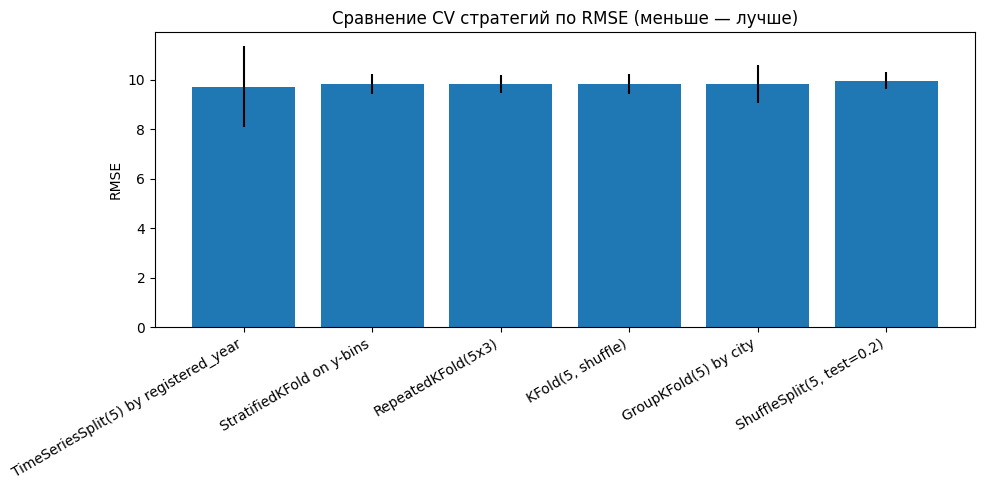

In [18]:
plt.figure(figsize=(10, 5))
plt.bar(res_df["cv"], res_df["RMSE_mean"], yerr=res_df["RMSE_std"])
plt.xticks(rotation=30, ha="right")
plt.title("Сравнение CV стратегий по RMSE (меньше — лучше)")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()
